In [1]:
import torch
import matplotlib.pyplot as plt

# Import the modules we just built
from src.dataset import KittiMotsDataset
from src.models.sam_wrapper import SAMWrapper
from src.prompts import get_prompts
from src.visualize import plot_prediction

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

/ghome/group05/miniconda3/envs/c5/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


In [2]:
# Path to your KITTI-MOTS dataset
data_dir = "/home/mcv/datasets/C5/KITTI-MOTS/" 

# Initialize the dataset (make sure return_masks=True so we can generate points!)
val_dataset = KittiMotsDataset(root_dir=data_dir, split="val", return_masks=True)
print(f"Loaded {len(val_dataset)} validation images.")

# Initialize SAM Wrapper
print("Loading SAM model (this might take a few seconds)...")
wrapper = SAMWrapper(device=device)
print("SAM Model loaded successfully!")

Loaded 2981 validation images.
Loading SAM model (this might take a few seconds)...


The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
Loading weights: 100%|██████████| 314/314 [00:00<00:00, 858.24it/s, Materializing param=vision_encoder.pos_embed]                                                  


SAM Model loaded successfully!


Found 3 objects in image 0.


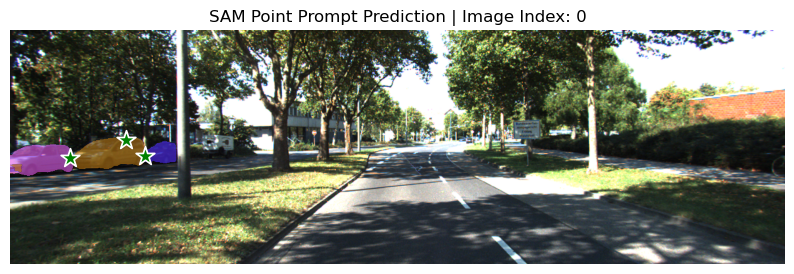

Predicted IoU Scores per object: [0.925, 0.932, 0.8]


In [7]:
# Change this index to explore different images in the validation set
image_idx = 0  

image, target = val_dataset[image_idx]

# Check if the image actually contains cars or pedestrians
if len(target["labels"]) == 0:
    print(f"Image {image_idx} has no objects. Try another index.")
else:
    print(f"Found {len(target['labels'])} objects in image {image_idx}.")

    # 1. Generate Point Prompts
    prompt_kwargs = get_prompts(target, prompt_type="point")
    
    # Extract the points and labels to pass to the visualizer
    pts = prompt_kwargs["input_points"][0]
    lbls = prompt_kwargs["input_labels"][0]
    
    # 2. Run Inference
    pred_masks, pred_scores = wrapper.predict(image, prompt_kwargs)
    
    # 3. Visualize the Results
    plot_prediction(
        image=image, 
        masks=pred_masks, 
        points=pts, 
        labels=lbls, 
        title=f"SAM Point Prompt Prediction | Image Index: {image_idx}"
    )
    
    print("Predicted IoU Scores per object:", [round(s, 3) for s in pred_scores])

In [ ]:
from src.models.grounded_sam_wrapper import GroundedSAMWrapper
from src.visualize import plot_presentation_quality

# Load wrapper
gd_wrapper = GroundedSAMWrapper(device=device)

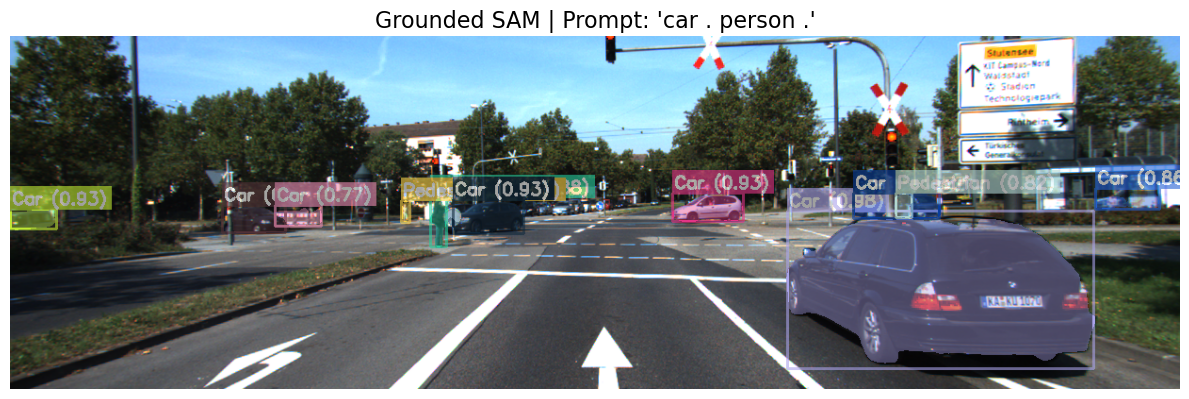

array([[[123, 176, 246],
        [123, 177, 242],
        [124, 179, 242],
        ...,
        [113, 175, 250],
        [114, 174, 252],
        [114, 171, 252]],

       [[123, 177, 242],
        [123, 177, 243],
        [124, 179, 243],
        ...,
        [117, 177, 250],
        [116, 177, 252],
        [114, 175, 251]],

       [[124, 177, 241],
        [124, 178, 243],
        [125, 182, 244],
        ...,
        [116, 176, 251],
        [115, 175, 251],
        [113, 175, 251]],

       ...,

       [[ 11,  11,  12],
        [ 11,  11,  13],
        [ 11,  11,  13],
        ...,
        [ 99,  92,  89],
        [ 95,  92,  89],
        [ 92,  93,  88]],

       [[ 11,  11,  12],
        [ 11,  11,  14],
        [ 11,  11,  16],
        ...,
        [ 99,  99,  97],
        [ 95,  97,  97],
        [ 91,  96,  94]],

       [[ 11,  12,  13],
        [ 11,  11,  15],
        [ 12,  11,  15],
        ...,
        [114, 107,  96],
        [113, 105,  97],
        [112, 102,  96]]

In [5]:
# Load image
image_idx = 100  
image, target = val_dataset[image_idx]

# Predict
masks, scores, boxes, int_labels, text_labels = gd_wrapper.predict(
    image, 
    text_prompt="car . person .",
    box_threshold=0.3,
    text_threshold=0.25
)

# Render the Hollywood-style plot!
plot_presentation_quality(
    image=image, 
    masks=masks, 
    boxes=boxes, 
    labels=text_labels, # Passes "Car" or "Pedestrian" instead of numbers
    scores=scores, 
    title=f"Grounded SAM | Prompt: 'car . person .'"
)

{'image_id': 0, 'category_id': 3, 'bbox': [0.0, 181.44387817382812, 104.89188385009766, 53.35289001464844], 'score': 0.9179087281227112}
{'image_id': 0, 'category_id': 3, 'bbox': [100.8421630859375, 169.74716186523438, 117.716552734375, 54.682891845703125], 'score': 0.8954987525939941}
{'image_id': 0, 'category_id': 3, 'bbox': [215.40689086914062, 179.1995391845703, 54.244476318359375, 36.19389343261719], 'score': 0.8352892994880676}
{'image_id': 0, 'category_id': 3, 'bbox': [308.3254699707031, 169.23521423339844, 51.803253173828125, 37.0262451171875], 'score': 0.2616112232208252}


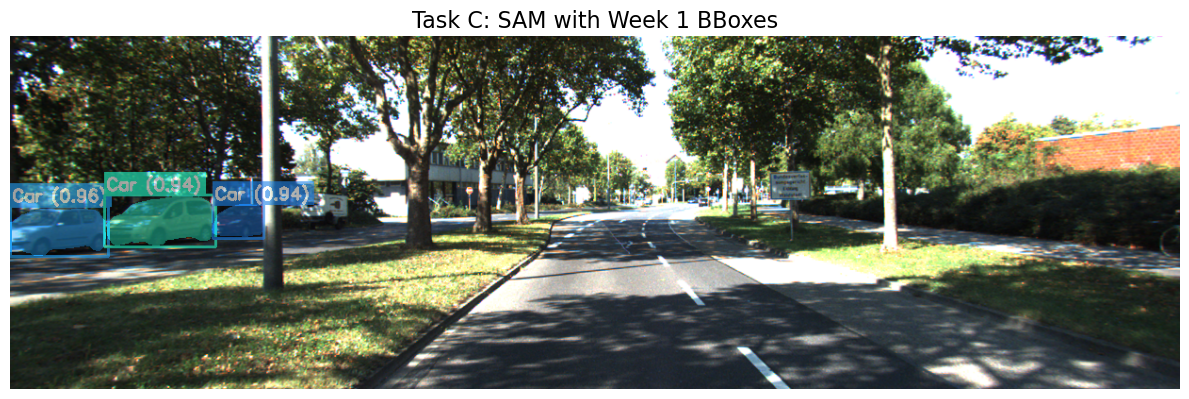

In [4]:
from src.prompts import get_prompts
from src.visualize import plot_presentation_quality

# Use your new config dictionary manually
task_c_config = {
    "prompt_type": "custom_bbox",
    "week1_predictions_path": "/ghome/group05/alvaro/MCV-C5/Task2/best_model_w1/week1_yolo_predictions.json",
    "custom_box_threshold": 0.5
}

image_idx = 0
image, target = val_dataset[image_idx]

# Extract Week 1 boxes
prompt_kwargs, pred_labels = get_prompts(target, prompt_type="custom_bbox", config=task_c_config)

if prompt_kwargs:
    # Run base SAM wrapper with Week 1 boxes
    masks, scores = wrapper.predict(image, prompt_kwargs)
    
    # FIX: Go one level deeper to unpack the boxes for the visualizer
    boxes = prompt_kwargs["input_boxes"][0][0] 
    
    # Map label integers to text for visualization
    class_name_map = {1: "Pedestrian", 3: "Car"}
    text_labels = [class_name_map.get(l, "Unknown") for l in pred_labels]
    
    plot_presentation_quality(
        image=image, 
        masks=masks, 
        boxes=boxes, 
        labels=text_labels,
        scores=scores, 
        title=f"Task C: SAM with Week 1 BBoxes"
    )
else:
    print("Your Week 1 model did not detect any confident objects in this image!")